<a href="https://colab.research.google.com/github/normala127/NLP_Yelp_Review_Project/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Big Data Analytics Project
## Predicting Restaurant Failure: An NLP Driven Risk Assesment from Yelp Reviews

Students: Hatidza Imamovic, Asja Basovic

### 1. Dataset creation and environment setup

Three datasets are needed to create the final dataset which will be used for analysis and model training. These are:
- business.json: holds data about each restaurant
- review.json: holds all the reviews for each restaurant
- checkin.json: holds the dates of all checked in visits in a given restaurant

Each is loaded and then combined in regards to the business_id to ensure a correct join. The final output is saved as final.json.


In [1]:
!pip install pyspark
!apt-get install openjdk-11-jdk-headless -qq > /dev/null


In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

In [3]:
from pyspark.sql import SparkSession

try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("ML Training Large Data") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.network.timeout", "800s") \
    .config("spark.executor.heartbeatInterval", "60s") \
    .config("spark.sql.broadcastTimeout", "1200") \
    .config("spark.sql.shuffle.partitions", "100") \
    .config("spark.default.parallelism", "100") \
    .getOrCreate()

print(spark)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
def show_shape(df):
  print((df.count(), len(df.columns)))

Imports for section 1.

In [8]:
from pyspark.sql.functions import col, count, hash

Loading the first dataset: business.json

In [9]:
df_business = spark.read.option("mode", "PERMISSIVE").json(r"/content/drive/MyDrive/yelp_academic_dataset_business.json")
df_business.printSchema()
df_business.show()

root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = true)
 |    |-- GoodForDancing: str

Loading the second dataset: review.json

In [10]:
df_review = spark.read.json(r"/content/drive/MyDrive/yelp_academic_dataset_review.json")

In [11]:
show_shape(df_business)

(150346, 14)


In [12]:
show_shape(df_review)

(6990280, 9)


Joining df_review and df_business into joined_df

In [13]:
df_review.createOrReplaceTempView("review")
df_business.createOrReplaceTempView("business")

In [14]:
joined_df = spark.sql("""
SELECT t1.*, t2.*
FROM review t1
LEFT JOIN business t2 ON t2.business_id = t1.business_id
""")
joined_df.show(5)

+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+---------------+--------------------+--------------------+--------------------+-------------+--------------------+-------+-------------+--------------+--------------------+-----------+------------+-----+-----+
|         business_id|cool|               date|funny|           review_id|stars|                text|useful|             user_id|        address|          attributes|         business_id|          categories|         city|               hours|is_open|     latitude|     longitude|                name|postal_code|review_count|stars|state|
+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+---------------+--------------------+--------------------+--------------------+-------------+--------------------+-------+-------------+--------------+--------------------+-----------+---------

In [15]:
joined_df = joined_df.drop(df_business['business_id'])

In [16]:
show_shape(joined_df)

(6990280, 22)


Loading the third dataset: checkin.json

In [17]:
df_checkin = spark.read.option("mode", "PERMISSIVE").json(r"/content/drive/MyDrive/yelp_academic_dataset_checkin.json")
df_checkin.printSchema()
df_checkin.show()

root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)

+--------------------+--------------------+
|         business_id|                date|
+--------------------+--------------------+
|---kPU91CF4Lq2-Wl...|2020-03-13 21:10:...|
|--0iUa4sNDFiZFrAd...|2010-09-13 21:43:...|
|--30_8IhuyMHbSOcN...|2013-06-14 23:29:...|
|--7PUidqRWpRSpXeb...|2011-02-15 17:12:...|
|--7jw19RH9JKXgFoh...|2014-04-21 20:42:...|
|--8IbOsAAxjKRoYsB...|2015-06-06 01:03:...|
|--9osgUCSDUWUkoTL...|2015-06-13 02:00:...|
|--ARBQr1WMsTWiwOK...|2014-12-12 00:44:...|
|--FWWsIwxRwuw9vIM...|2010-09-11 16:28:...|
|--FcbSxK1AoEtEAxO...|2017-08-18 19:43:...|
|--LC8cIrALInl2vyo...|2017-01-12 19:10:...|
|--MbOh2O1pATkXa7x...|2013-04-21 01:52:...|
|--N9yp3ZWqQIm7DqK...|2012-10-06 20:46:...|
|--O3ip9NpXTKD4oBS...|2010-04-17 21:07:...|
|--OS_I7dnABrXvRCC...| 2018-05-11 18:23:36|
|--S43ruInmIsGrnnk...|2010-08-29 01:17:...|
|--SJXpAa0E-GCp2sm...|2014-04-06 22:23:...|
|--Sd93OFWITqDHifM...|2013-01-09 17

In [18]:
df_checkin_new=df_checkin.withColumnRenamed('date', 'date_checkin')
df_checkin_new.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- date_checkin: string (nullable = true)



Joining joined_df (review+business) and df_checkin into joined_df2

In [19]:
df_checkin_new.createOrReplaceTempView('checkin')
joined_df.createOrReplaceTempView('joined_df')

In [20]:
joined_df2 = spark.sql("""
SELECT t1.*, t2.date_checkin
FROM joined_df t1
JOIN checkin t2 ON t2.business_id = t1.business_id
""")
joined_df2.show(5)

+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+--------------------+--------------------+--------------------+----+--------------------+-------+----------+-----------+--------------------+-----------+------------+-----+-----+--------------------+
|         business_id|cool|               date|funny|           review_id|stars|                text|useful|             user_id|             address|          attributes|          categories|city|               hours|is_open|  latitude|  longitude|                name|postal_code|review_count|stars|state|        date_checkin|
+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+--------------------+--------------------+--------------------+----+--------------------+-------+----------+-----------+--------------------+-----------+------------+-----+-----+--------------------+
|-0iIxySkp97W

In [21]:
joined_df2.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- cool: long (nullable = true)
 |-- date: string (nullable = true)
 |-- funny: long (nullable = true)
 |-- review_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- text: string (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: 

In [22]:
keywords = "Restaurant|Restaurants"
restaurant_df = joined_df2.filter(col('categories').rlike(keywords))

In [23]:
show_shape(restaurant_df)

(4715168, 23)


In [24]:
restaurant_df.groupBy('is_open').agg(count('review_id').alias('c')).show()

+-------+-------+
|is_open|      c|
+-------+-------+
|      0| 945589|
|      1|3769579|
+-------+-------+



Checking the distribution of opened and closed retaurants

In [25]:
df_isOpen=restaurant_df.filter(restaurant_df['is_open']==1)
df_isOpen.show()

+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+--------------------+--------------------+--------------------+----+--------------------+-------+----------+-----------+--------------------+-----------+------------+-----+-----+--------------------+
|         business_id|cool|               date|funny|           review_id|stars|                text|useful|             user_id|             address|          attributes|          categories|city|               hours|is_open|  latitude|  longitude|                name|postal_code|review_count|stars|state|        date_checkin|
+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+--------------------+--------------------+--------------------+----+--------------------+-------+----------+-----------+--------------------+-----------+------------+-----+-----+--------------------+
|-0iIxySkp97W

In [26]:
df_isClosed=restaurant_df.filter(restaurant_df['is_open']==0)
df_isClosed.show()

+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+-------+----------+-----------+------------------+-----------+------------+-----+-----+--------------------+
|         business_id|cool|               date|funny|           review_id|stars|                text|useful|             user_id|             address|          attributes|          categories|        city|               hours|is_open|  latitude|  longitude|              name|postal_code|review_count|stars|state|        date_checkin|
+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+-------+----------+-----------+------------------+-----------+------------+-----+-----+-----------------

Dropping a part of open restaurants based on business_id to balance out the classes

In [27]:
id_labels = restaurant_df.select("business_id", "is_open").distinct()

majority_ids = id_labels.filter(col("is_open") == 1) \
    .withColumn("keep", (hash("business_id") % 10000) < 5)

In [28]:
minority_ids = id_labels.filter(col("is_open") == 0) \
    .withColumn("keep", (hash("business_id") % 100) < 50)

In [29]:
ids_to_keep = majority_ids.filter("keep").union(
    minority_ids.select("business_id", 'is_open', 'keep')
)

balanced_df = restaurant_df.join(ids_to_keep.select("business_id"),
                      "business_id")

In [30]:
show_shape(balanced_df)

(2849453, 23)


In [31]:
show_shape(majority_ids)

(34531, 3)


In [32]:
show_shape(minority_ids)

(16787, 3)


In [33]:
balanced_df.groupBy('is_open').agg(count('review_id').alias('c')).show()

+-------+-------+
|is_open|      c|
+-------+-------+
|      0| 945589|
|      1|1903864|
+-------+-------+



In [83]:
stratified_df = balanced_df.sampleBy('is_open', fractions={0: 0.10, 1: 0.05}, seed=42)

In [35]:
stratified_df.groupBy('is_open').agg(count('review_id').alias('c')).show()

+-------+-----+
|is_open|    c|
+-------+-----+
|      0|94486|
|      1|95227|
+-------+-----+



Renaming columns and dropping uneeded columns

In [36]:
stratified_df.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- cool: long (nullable = true)
 |-- date: string (nullable = true)
 |-- funny: long (nullable = true)
 |-- review_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- text: string (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: 

In [37]:
cols=stratified_df.columns
stars_columns=[i for i, c in enumerate(cols) if c=='stars']

cols[stars_columns[0]]='stars_review'
cols[stars_columns[1]]='stars_business'

stratified_df=stratified_df.toDF(*cols)

In [38]:
stratified_df.columns

['business_id',
 'cool',
 'date',
 'funny',
 'review_id',
 'stars_review',
 'text',
 'useful',
 'user_id',
 'address',
 'attributes',
 'categories',
 'city',
 'hours',
 'is_open',
 'latitude',
 'longitude',
 'name',
 'postal_code',
 'review_count',
 'stars_business',
 'state',
 'date_checkin']

In [39]:
final_df=stratified_df.drop(*['cool', 'funny', 'useful', 'latitude', 'longitude', 'postal_code', 'attributes', 'hours', 'categories'])

In [40]:
final_df.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- stars_review: double (nullable = true)
 |-- text: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- address: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- name: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars_business: double (nullable = true)
 |-- state: string (nullable = true)
 |-- date_checkin: string (nullable = true)



In [41]:
show_shape(final_df)

(189195, 14)


### 1.5 EDA

Imports for section 1.5.

In [42]:
from pyspark.sql.functions import col, countDistinct
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, when, count, row_number
from pyspark.sql.window import Window

/tmp/ipykernel_21963/1300874827.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_pd, y="name", x="review_count", palette="Blues_r", ax=ax1)
/tmp/ipykernel_21963/1300874827.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10_pd, y="name", x="review_count", palette="Reds_r", ax=ax2)


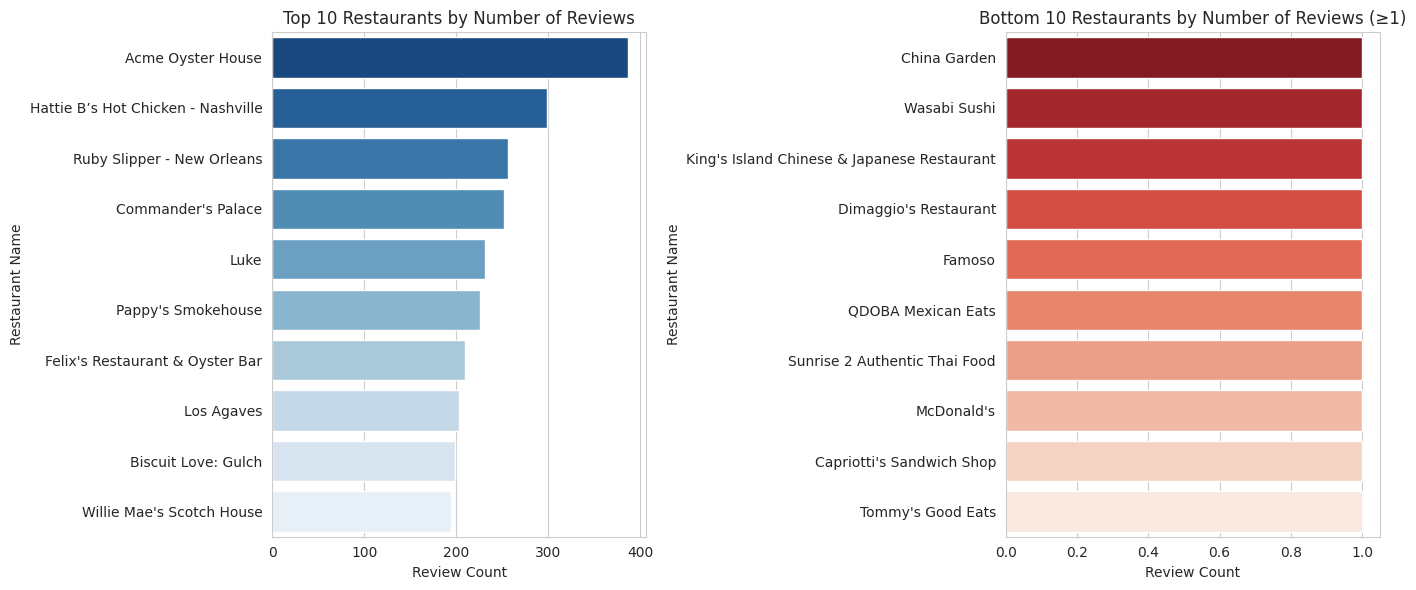

In [43]:
review_counts = final_df.groupBy("business_id", "name") \
    .agg(count("*").alias("review_count"))


top10 = review_counts.orderBy(col("review_count").desc()).limit(10)
bottom10 = review_counts.orderBy(col("review_count").asc()).limit(10)

top10_pd = top10.toPandas()
bottom10_pd = bottom10.toPandas()

sns.set_style("whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top10_pd, y="name", x="review_count", palette="Blues_r", ax=ax1)
ax1.set_title("Top 10 Restaurants by Number of Reviews")
ax1.set_xlabel("Review Count")
ax1.set_ylabel("Restaurant Name")

sns.barplot(data=bottom10_pd, y="name", x="review_count", palette="Reds_r", ax=ax2)
ax2.set_title("Bottom 10 Restaurants by Number of Reviews (≥1)")
ax2.set_xlabel("Review Count")
ax2.set_ylabel("Restaurant Name")

plt.tight_layout()
plt.show()

/tmp/ipykernel_21963/2895851846.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=biz_state_pd.head(10), y="state", x="num_businesses", palette="rocket")


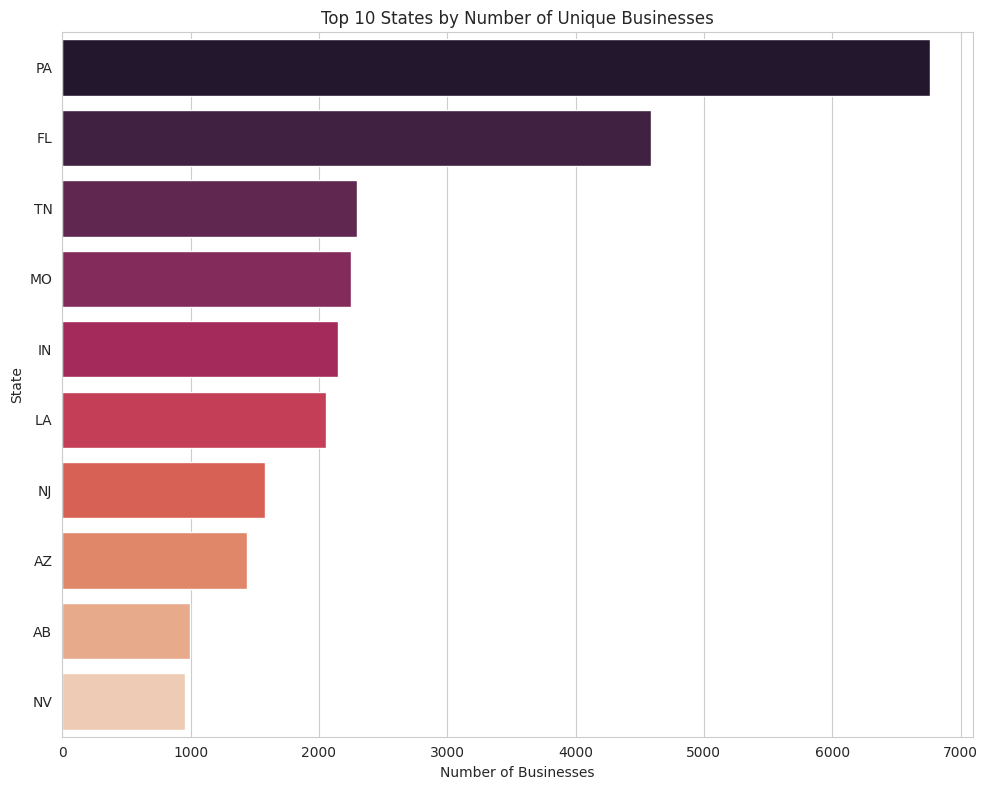

In [44]:
businesses_by_state = final_df.filter(col("state").isNotNull()) \
    .groupBy("state") \
    .agg(countDistinct("business_id").alias("num_businesses")) \
    .orderBy(col("num_businesses").desc())

biz_state_pd = businesses_by_state.toPandas()

plt.figure(figsize=(10, 8))
sns.barplot(data=biz_state_pd.head(10), y="state", x="num_businesses", palette="rocket")
plt.title("Top 10 States by Number of Unique Businesses")
plt.xlabel("Number of Businesses")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [45]:
cities_by_state = final_df.filter(col("state")=='PA') \
    .groupBy("city") \
    .agg(countDistinct("business_id").alias("num_businesses")) \
    .orderBy(col("num_businesses").desc())

biz_city_pd = cities_by_state.toPandas()

/tmp/ipykernel_21963/2605707215.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=biz_city_pd.head(20), x="city", y="num_businesses", palette="viridis")


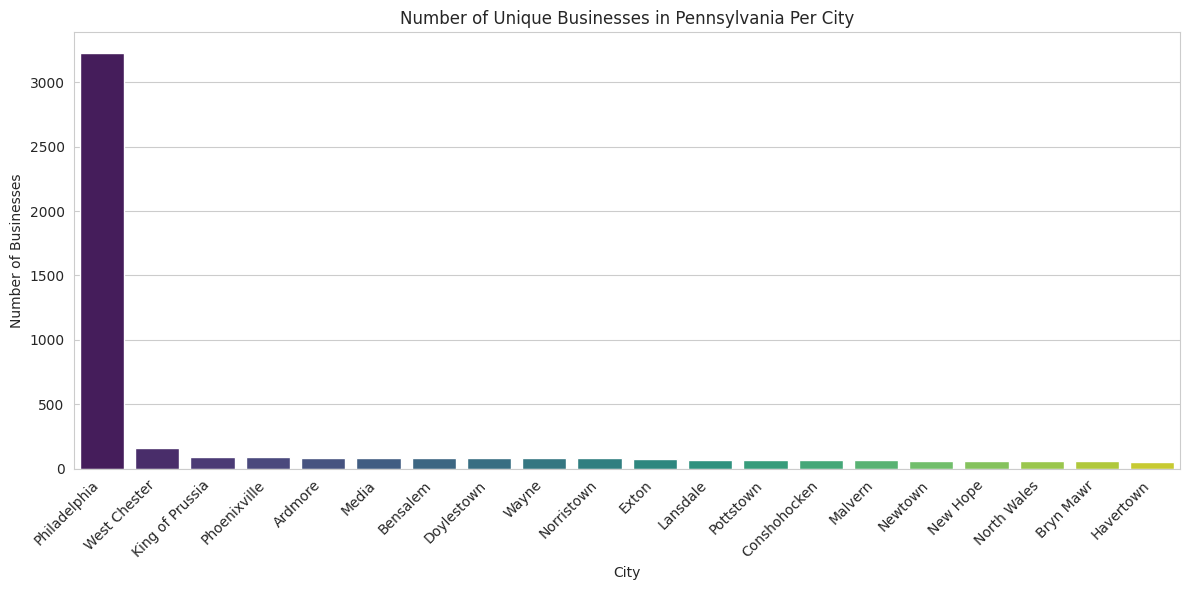

In [46]:
plt.figure(figsize=(12, 6))
sns.barplot(data=biz_city_pd.head(20), x="city", y="num_businesses", palette="viridis")
plt.title("Number of Unique Businesses in Pennsylvania Per City")
plt.xlabel("City")
plt.ylabel("Number of Businesses")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

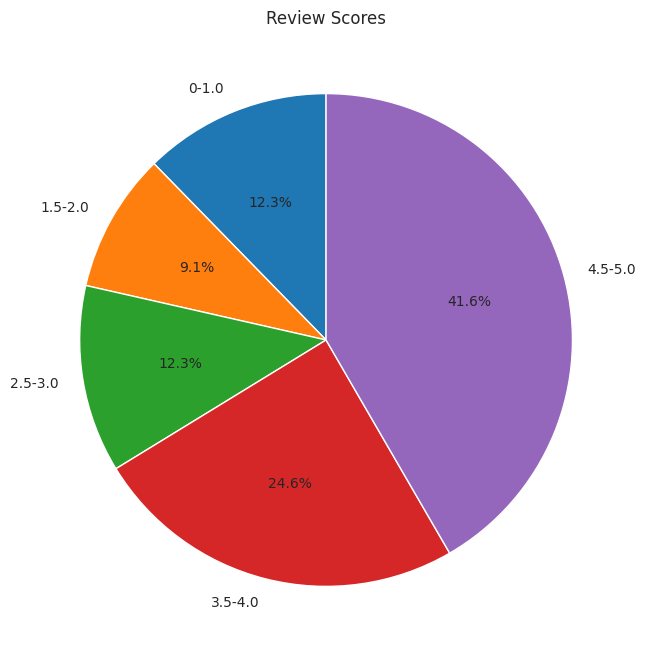

In [47]:
df_grouped = final_df.withColumn(
    "rating_group",
    when(col("stars_review") <= 1.0, "0-1.0")
    .when(col("stars_review") <= 2.0, "1.5-2.0")
    .when(col("stars_review") <= 3.0, "2.5-3.0")
    .when(col("stars_review") <= 4.0, "3.5-4.0")
    .otherwise("4.5-5.0")
)

group_counts = df_grouped.groupBy("rating_group").count().orderBy("rating_group")
group_counts_pd = group_counts.toPandas()

plt.figure(figsize=(8,8))
plt.pie(group_counts_pd["count"],
        labels=group_counts_pd["rating_group"],
        autopct='%1.1f%%',
        startangle=90)
plt.title("Review Scores")
plt.show()

### 2. Preprocessing

Firstly, on a global level, null and duplicate values were dropped.

This section covers:
- lowercase,
- keep only letters (and numbers) and spaces,
- remove extra spaces,
- remove private information,
- remove emojis, urls,
- keep '!' and '?' where needed.

It creates a pipeline for TF-IDF and for semantic analysis as slightly different cleaning techniques are used for each. The section also uses n-grams, and handles "not" negation effectively.

For non-review data a function for cleaning is covered while scaling was done before building the models (since that is when we have the train test splits done). The function does the following:
- text data is turned to lowercase and keeps only letters, and removes extra spaces;
- dates are formated correctly and for date checkin only the latest timestamp is extracted.


Imports for section 2 and section 3.

In [48]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from pyspark.sql.functions import when, col, count, sum, month, day, year
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, FloatType

import numpy as np

from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF, NGram, VectorAssembler, StandardScaler, MinMaxScaler
from pyspark.ml.classification import LogisticRegression, NaiveBayes, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [49]:
df = final_df.select("*")
df.show()

+--------------------+-------------------+--------------------+------------+--------------------+--------------------+--------------------+------------+-------+--------------------+------------+--------------+-----+--------------------+
|         business_id|               date|           review_id|stars_review|                text|             user_id|             address|        city|is_open|                name|review_count|stars_business|state|        date_checkin|
+--------------------+-------------------+--------------------+------------+--------------------+--------------------+--------------------+------------+-------+--------------------+------------+--------------+-----+--------------------+
|-0iIxySkp97WNlwK6...|2015-10-19 04:01:56|dKwOJzm42FjN_r3wL...|         5.0|The staff are sup...|ruVTzBQ1xHkOxQCyQ...|538 S Virginia St...|        Reno|      1|Truckee Bagel Com...|         219|           3.5|   NV|2015-07-01 18:39:...|
|-0iIxySkp97WNlwK6...|2016-05-09 06:08:49|SjB0GahfiP

In [50]:
null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])

null_counts_pd = null_counts.toPandas().T
null_counts_pd.columns = ['Null Count']
null_counts_pd.index.name = 'Column'

null_counts.show()

+-----------+----+---------+------------+----+-------+-------+----+-------+----+------------+--------------+-----+------------+
|business_id|date|review_id|stars_review|text|user_id|address|city|is_open|name|review_count|stars_business|state|date_checkin|
+-----------+----+---------+------------+----+-------+-------+----+-------+----+------------+--------------+-----+------------+
|          0|   0|        0|           0|   0|      0|      0|   0|      0|   0|           0|             0|    0|           0|
+-----------+----+---------+------------+----+-------+-------+----+-------+----+------------+--------------+-----+------------+



In [51]:
df = df.dropDuplicates(['text'])
show_shape(df)

(189684, 14)


In [52]:
def clean_sentiment(df):
    return df.withColumn("text_cleaned_sentiment",
        F.trim(F.regexp_replace(
            F.regexp_replace(
                  F.regexp_replace(
                      F.regexp_replace(
                          F.lower(F.regexp_replace(F.col("text"), r'!+', ' ! ')),
                          r'\?+', ' ? '
                      ),
                      r"http\S+|www\S+|\S+@\S+", " "
                  ),
              r'[^a-z0-9\s!?_]', ' '
            ),
            r'\s+', ' '
        ))
    )

In [53]:
def clean_tfidf(df):
    return df.withColumn("text_cleaned",
        F.trim(
            F.regexp_replace(
                F.regexp_replace(
                    F.lower(F.col("text")),
                    r"http\S+|www\S+|\S+@\S+", " "
                ),
                r'[^A-Za-z\s]', " "
            )
        )
    ).withColumn("text_cleaned", F.regexp_replace(F.col("text_cleaned"), r"\s+", " "))

In [54]:
df=clean_tfidf(df)
df=clean_sentiment(df)
df.show(5)

+--------------------+-------------------+--------------------+------------+--------------------+--------------------+--------------------+------------+-------+--------------------+------------+--------------+-----+--------------------+--------------------+----------------------+
|         business_id|               date|           review_id|stars_review|                text|             user_id|             address|        city|is_open|                name|review_count|stars_business|state|        date_checkin|        text_cleaned|text_cleaned_sentiment|
+--------------------+-------------------+--------------------+------------+--------------------+--------------------+--------------------+------------+-------+--------------------+------------+--------------+-----+--------------------+--------------------+----------------------+
|zi0gBCtnESAbVKRNY...|2017-09-25 01:02:38|NswgPmPVo2dMuulhK...|         1.0|$20. Bad service....|VFARdsYBNINbTmJVu...|129 Concord Plaza...| Saint Louis|     

Cleaning other columns (not including any IDs, review and business stars, review count and is open)

In [55]:
def clean_columns(df):
  df = df.withColumn("city_cleaned", F.trim(F.lower(F.col("city")))
          ) \
          .withColumn("state_cleaned", F.trim(F.lower(F.col("state")))
          ) \
          .withColumn("address_cleaned", F.trim(F.lower(F.regexp_replace(F.col("address"), r"\s+", " ")))
          ) \
          .withColumn("name_cleaned", F.trim(F.lower(F.regexp_replace(F.regexp_replace(F.col("name"), r"[^\p{L}\s]", ""), r"\s+", " ")))
          ) \
          .withColumn("date_parsed", F.to_date(F.col("date"), "yyyy-MM-dd HH:mm:ss")
          ) \
          .withColumn("last_checkin_date", F.to_date(F.when(F.col("date_checkin").contains(","), F.trim(F.reverse(F.split(F.col("date_checkin"), ",")).getItem(0))).otherwise(F.col('date_checkin'))))
  df=df.drop("city", "state","address", "name", "date", "date_checkin")
  return df

In [56]:
df2 = clean_columns(df)
df2.show(5)

+--------------------+--------------------+------------+--------------------+--------------------+-------+------------+--------------+--------------------+----------------------+------------+-------------+--------------------+--------------------+-----------+-----------------+
|         business_id|           review_id|stars_review|                text|             user_id|is_open|review_count|stars_business|        text_cleaned|text_cleaned_sentiment|city_cleaned|state_cleaned|     address_cleaned|        name_cleaned|date_parsed|last_checkin_date|
+--------------------+--------------------+------------+--------------------+--------------------+-------+------------+--------------+--------------------+----------------------+------------+-------------+--------------------+--------------------+-----------+-----------------+
|zi0gBCtnESAbVKRNY...|NswgPmPVo2dMuulhK...|         1.0|$20. Bad service....|VFARdsYBNINbTmJVu...|      1|         141|           3.0|bad service assho...|  20 bad se

### 3. Feature engineering

This section covers the creation of new features:
- dates: months and days are encoded using sine and cosine transformations so the models can learn the cyclical patterns; years are extracted to discover linear patterns.
- TF-IDF: unigrams and bigrams are identified.
- sentiment analysis: three ML models are compared to see which creates the most accurate sentiment.
- train/test split: 80/20 split of unique business to avoid data leakage.

In [57]:
def extract_dates(df):
  d = df.withColumn('month', F.month('date_parsed')) \
  .withColumn('month_checkin', F.month('last_checkin_date')) \
  .withColumn('day', F.day('date_parsed')) \
  .withColumn('day_checkin', F.day('last_checkin_date')) \
  .withColumn('year', F.year('date_parsed')) \
  .withColumn('year_checkin', F.year('last_checkin_date'))

  d=d.drop('date_parsed', 'last_checkin_date')
  return d

In [58]:
def encode_dates(df):
  d = df.withColumn("month_sin", F.sin(2 * np.pi * F.col("month") / 12)) \
  .withColumn("month_cos", F.cos(2 * np.pi * F.col("month") / 12)) \
  .withColumn('day_sin', F.sin(2 * np.pi * F.col("day") / 7)) \
  .withColumn('day_cos', F.cos(2 * np.pi * F.col("day") / 7)) \
  .withColumn("month_checkin_sin", F.sin(2 * np.pi * F.col("month_checkin") / 12)) \
  .withColumn("month_checkin_cos", F.cos(2 * np.pi * F.col("month_checkin") / 12)) \
  .withColumn('day_checkin_sin', F.sin(2 * np.pi * F.col("day_checkin") / 7)) \
  .withColumn('day_checkin_cos', F.cos(2 * np.pi * F.col("day_checkin") / 7))

  d = d.drop('month', 'day', 'month_checkin', 'day_checkin')
  return d

In [59]:
df3=extract_dates(df2)
df3.show(5)

+--------------------+--------------------+------------+--------------------+--------------------+-------+------------+--------------+--------------------+----------------------+------------+-------------+--------------------+--------------------+-----+-------------+---+-----------+----+------------+
|         business_id|           review_id|stars_review|                text|             user_id|is_open|review_count|stars_business|        text_cleaned|text_cleaned_sentiment|city_cleaned|state_cleaned|     address_cleaned|        name_cleaned|month|month_checkin|day|day_checkin|year|year_checkin|
+--------------------+--------------------+------------+--------------------+--------------------+-------+------------+--------------+--------------------+----------------------+------------+-------------+--------------------+--------------------+-----+-------------+---+-----------+----+------------+
|zi0gBCtnESAbVKRNY...|NswgPmPVo2dMuulhK...|         1.0|$20. Bad service....|VFARdsYBNINbTmJVu

In [60]:
df4=encode_dates(df3)
df4.show(5)

+--------------------+--------------------+------------+--------------------+--------------------+-------+------------+--------------+--------------------+----------------------+------------+-------------+--------------------+--------------------+----+------------+-------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-------------------+-------------------+
|         business_id|           review_id|stars_review|                text|             user_id|is_open|review_count|stars_business|        text_cleaned|text_cleaned_sentiment|city_cleaned|state_cleaned|     address_cleaned|        name_cleaned|year|year_checkin|          month_sin|           month_cos|             day_sin|            day_cos|   month_checkin_sin|   month_checkin_cos|    day_checkin_sin|    day_checkin_cos|
+--------------------+--------------------+------------+--------------------+--------------------+-------+------------+--------------+------

In [61]:
remover = StopWordsRemover()
default_stops = remover.getStopWords()
updated_stops = [w for w in default_stops if w != 'not']

def tfidf(vocab_size = 5000, min_df = 50, suffix = ""):

  tokenizer = RegexTokenizer(
      inputCol="text_cleaned"+suffix,
      outputCol="tokens_raw"+suffix,
      pattern=r"\W+",
      gaps=True,
      toLowercase=True,
      minTokenLength=1
  )

  remover = StopWordsRemover(inputCol="tokens_raw"+suffix, outputCol="filtered_tokens"+suffix, stopWords=updated_stops)

  ngram = NGram(n=2, inputCol="filtered_tokens"+suffix, outputCol="bigrams"+suffix)

  uni_vectorizer = CountVectorizer(
        inputCol="filtered_tokens"+suffix,
        outputCol="uni_count_features"+suffix,
        vocabSize=vocab_size,
        minDF=min_df
    )

  bi_vectorizer = CountVectorizer(
      inputCol = 'bigrams'+suffix,
      outputCol = "bi_count_features"+suffix,
      vocabSize = vocab_size,
      minDF=min_df
  )

  assembler = VectorAssembler(
        inputCols=["uni_count_features"+suffix, "bi_count_features"+suffix],
        outputCol="combined_counts"+suffix
    )

  idf = IDF(inputCol="combined_counts"+suffix, outputCol="features"+suffix)

  return  [tokenizer, remover, ngram, uni_vectorizer, bi_vectorizer, assembler, idf]


In [62]:
tfidf_pipeline_stages = tfidf()
tfidf_pipeline = Pipeline(stages=tfidf_pipeline_stages)

In [63]:
df4 = df4.withColumn('stars_review_binary', when(df4['stars_review']<3, 0).otherwise(1))

In [64]:
def get_log_reg(suffix):
    return LogisticRegression(
        featuresCol=f'features{suffix}',
        labelCol='stars_review_binary',
        predictionCol=f'prediction{suffix}',
        probabilityCol=f'probability{suffix}',
        regParam=0.3,
        maxIter=10
    )

def get_naive_bayes(suffix):
    return NaiveBayes(
        featuresCol=f'features{suffix}',
        labelCol='stars_review_binary',
        predictionCol=f'prediction{suffix}',
        probabilityCol=f'probability{suffix}',
        modelType="multinomial"
    )

def get_random_forest(suffix):
    return RandomForestClassifier(
        featuresCol=f'features{suffix}',
        labelCol='stars_review_binary',
        predictionCol=f'prediction{suffix}',
        numTrees=20
    )

In [65]:
df4.cache()

models = [
    ("Logistic Regression", get_log_reg("_sentiment")),
    ("Naive Bayes", get_naive_bayes("_sentiment")),
    ("Random Forest", get_random_forest("_sentiment"))
]

results = []
evaluator = MulticlassClassificationEvaluator(
    labelCol="stars_review_binary",
    predictionCol="prediction_sentiment",
    metricName="accuracy"
)

for name, model in models:
    current_stages = tfidf(suffix="_sentiment")
    current_stages.append(model)

    pipeline = Pipeline(stages=current_stages)

    train_data, test_data = df4.randomSplit([0.8, 0.2], seed=42)

    fitted_model = pipeline.fit(train_data)
    predictions = fitted_model.transform(test_data)

    accuracy = evaluator.evaluate(predictions)
    results.append((name, accuracy))
    print(f"{name} Accuracy: {accuracy:.4f}")

print("\nFinal Results")
for name, acc in results:
    print(f"{name}: {acc}")

Logistic Regression Accuracy: 0.9003
Naive Bayes Accuracy: 0.9048
Random Forest Accuracy: 0.7853

Final Results
Logistic Regression: 0.9002910822969039
Naive Bayes: 0.9048425509394019
Random Forest: 0.7853135750198466


In [66]:
def sentiment_analysis(suffix="_sentiment"):
  stages = tfidf(suffix="_sentiment")

  nb = NaiveBayes(
        featuresCol=f'features{suffix}',
        labelCol='stars_review_binary',
        predictionCol=f'prediction{suffix}',
        probabilityCol=f'probability{suffix}',
        modelType="multinomial"
    )

  stages.append(nb)

  return stages

In [67]:
sentiment_analysis_pipeline_stages = sentiment_analysis()
sentiment_analysis_pipeline = Pipeline(stages=sentiment_analysis_pipeline_stages)

In [68]:
unique_bus_df = df4.select("business_id", "is_open").distinct()

fractions = {0: 0.8, 1: 0.8}

train_ids = unique_bus_df.sampleBy("is_open", fractions, seed=42)

test_ids = unique_bus_df.join(train_ids, on="business_id", how="left_anti")

train_df = df4.join(train_ids.select("business_id"), on="business_id", how="inner")
test_df = df4.join(test_ids.select("business_id"), on="business_id", how="inner")

In [69]:
sentiment_model = sentiment_analysis_pipeline.fit(train_df)
tfidf_model = tfidf_pipeline.fit(train_df)

def prepare_features(input_df):
    df_with_sent = sentiment_model.transform(input_df)

    df_clean = df_with_sent.withColumn(
        "sentiment_score",
        vector_to_array(F.col("probability_sentiment"))[1]
    ).drop(
        "tokens_raw_sentiment", "filtered_tokens_sentiment",
        "uni_count_features_sentiment", "bi_count_features_sentiment",
        "combined_counts_sentiment", "features_sentiment"
    )

    return tfidf_model.transform(df_clean)

train_final = prepare_features(train_df)
test_final = prepare_features(test_df)

In [79]:
uni_vocab = tfidf_model.stages[3].vocabulary
bi_vocab = tfidf_model.stages[4].vocabulary

full_vocabulary = uni_vocab + bi_vocab

idf_weights = tfidf_model.stages[6].idf.toArray()

word_scores = list(zip(full_vocabulary, idf_weights))

df_tfidf = pd.DataFrame(word_scores, columns=['word', 'score'])
top10 = df_tfidf.sort_values(by='score', ascending=False).head(10)

print(top10)

            word     score
4978        cats  7.851371
4900      garces  7.534459
4619       zahav  7.534459
4999    scrapple  7.522189
4345         spa  7.510068
9818  tomato pie  7.510068
4814      willie  7.510068
4232         que  7.498092
4896      saigon  7.486257
9527     wow wow  7.474561


/tmp/ipykernel_21963/3375373193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='word', data=top10, palette='viridis')


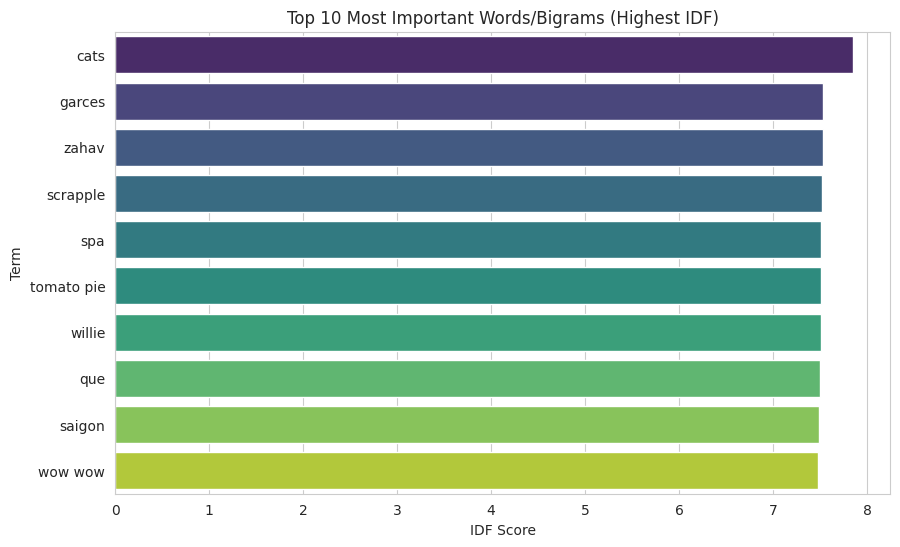

In [80]:
plt.figure(figsize=(10, 6))
sns.barplot(x='score', y='word', data=top10, palette='viridis')
plt.title('Top 10 Most Important Words/Bigrams (Highest IDF)')
plt.xlabel('IDF Score')
plt.ylabel('Term')
plt.show()

### 4. Building models

The section covers the implementation for four machine learning algorithms:
- SVM
- Logistic Regression
- Random Forest

All three algorithms were identified through a literature review and were deemed suitable for the given problem.

Imports for section 4 and section 5.

In [72]:
from pyspark.ml.classification import LinearSVC, LogisticRegression, RandomForestClassifier
from xgboost.spark import SparkXGBClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler, MinMaxScaler
import pandas as pd
import gc
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder


In [73]:
def get_all_metrics(predictions):
    eval_multiclass = MulticlassClassificationEvaluator(labelCol="is_open", predictionCol="prediction2")
    eval_binary = BinaryClassificationEvaluator(labelCol="is_open", rawPredictionCol="rawPrediction2")

    return {
        'auc_roc': eval_binary.setMetricName('areaUnderROC').evaluate(predictions),
        'accuracy': eval_multiclass.setMetricName('accuracy').evaluate(predictions),
        'f1': eval_multiclass.setMetricName('f1').evaluate(predictions),
        'precision': eval_multiclass.setMetricName('weightedPrecision').evaluate(predictions),
        'recall': eval_multiclass.setMetricName('weightedRecall').evaluate(predictions)
    }

In [74]:
def get_svm(featuresCol="assembled_features", labelCol="is_open"):
    return LinearSVC(
        featuresCol=featuresCol,
        labelCol=labelCol,
        predictionCol="prediction2",
        rawPredictionCol="rawPrediction2",
        maxIter=100,
        regParam=0.1,
        tol=1e-6,
        standardization=True
    )

def get_log_reg(featuresCol="assembled_features", labelCol="is_open"):
    return LogisticRegression(
        featuresCol=featuresCol,
        labelCol=labelCol,
        predictionCol="prediction2",
        rawPredictionCol="rawPrediction2",
        probabilityCol="probability2",
        maxIter=100,
        regParam=0.0,
        elasticNetParam=0.0,
        family="auto",
        standardization=False,
        threshold=0.5
    )

def get_rand_forest(featuresCol="assembled_features", labelCol="is_open"):
      return RandomForestClassifier(
          featuresCol=featuresCol,
          labelCol=labelCol,
          predictionCol='prediction2',
          rawPredictionCol='rawPrediction2',
          probabilityCol='probability2',
          featureSubsetStrategy="auto",
          seed=42,
          numTrees=20,
          maxDepth=10
      )

In [75]:
train_final.cache()

feature_columns = [col for col in train_final.columns if col not in [
    'is_open', "text", 'business_id', 'review_id', 'tokens_raw', 'filtered_tokens',
    'bigrams', 'uni_count_features', 'bi_count_features', 'combined_counts',
    'bigrams_sentiment', 'rawPrediction', 'stars_review', 'user_id', 'text_cleaned',
    'text_cleaned_sentiment', 'state_cleaned', 'name_cleaned', 'address_cleaned', 'city_cleaned'
]]

assembler = VectorAssembler(inputCols=feature_columns, outputCol="raw_features_scaling", handleInvalid="keep")
train_assembled = assembler.transform(train_final)
test_assembled = assembler.transform(test_final)

std_scaler = StandardScaler(inputCol="raw_features_scaling", outputCol="assembled_features", withMean=True, withStd=True)
std_model = std_scaler.fit(train_assembled)
std_train = std_model.transform(train_assembled)
std_test = std_model.transform(test_assembled)

In [76]:
models = [
    ('SVM',     get_svm()),
    ('RF',      get_rand_forest()),
    ('LogReg',  get_log_reg())
]

results = []
trained_models={}
prediction_models={}

for name, model in models:
    gc.collect()
    spark.sparkContext._jvm.System.gc()

    pipeline = Pipeline(stages=[model])

    try:
        fitted_model = pipeline.fit(std_train)
        predictions = fitted_model.transform(std_test)

        trained_models[name]=fitted_model
        prediction_models[name]=predictions.cache()

        metrics = get_all_metrics(predictions)
        metrics['model'] = name
        results.append(metrics)
        print(f"{name} - AUC: {metrics['auc_roc']:.4f}, Accuracy: {metrics['accuracy']:.4f}")

    except Exception as e:
        print(f"Error with {name}: {str(e)}")

if results:
    results_df = pd.DataFrame(results)
    results_df = results_df[['model', 'auc_roc', 'accuracy', 'f1', 'precision', 'recall']]
    print("Model performance table:")
    print(results_df.round(4).to_string(index=False))

SVM - AUC: 0.9525, Accuracy: 0.8839
RF - AUC: 0.8925, Accuracy: 0.8102
LogReg - AUC: 0.9583, Accuracy: 0.8998
Model performance table:
 model  auc_roc  accuracy     f1  precision  recall
   SVM   0.9525    0.8839 0.8839     0.8850  0.8839
    RF   0.8925    0.8102 0.8102     0.8112  0.8102
LogReg   0.9583    0.8998 0.8998     0.9004  0.8998


Saving the final dataset and exporting random 100 rows to csv.

In [77]:
final_dataset_df = prediction_models['LogReg'].select('business_id', *feature_columns, 'review_id', 'text', 'text_cleaned', 'text_cleaned_sentiment', "is_open", 'rawPrediction2', 'probability2',"prediction2")

final = final_dataset_df.orderBy(F.rand(seed=42)).limit(100).toPandas()

final.to_csv("final_dataset.csv", index=False)

In [82]:
rf_errors = prediction_models['LogReg'].filter("prediction2 = 1 AND is_open = 0")

print("Restaurants the Logistic Regression predicted would stay open, but actually closed:")
rf_errors.select("business_id", "probability2", "text").show(10, truncate=False)

Restaurants the Logistic Regression predicted would stay open, but actually closed:
+----------------------+----------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------